<h1><center> TP d’Initiation au Traitement du Signal </center></h1>

<h2><center>Consignes</center></h2>
 
1. Le fichier .ipynb doit être enregistré sous la forme: *votre_Nom_Prenom.ipynb* et être déposé sous Moodle.
1.Chacune de vos réponses aux questions doit avoir un code source et des résultats numériques ou des images et/ou bien des commentaires associés.
***

<h3><center>EXERCICE 1 : ÉCHANTILLONNAGE</center></h3>

On considère le signal analogique $y(t) = cos(2πf0t)$ avec $t$ $∈$ $R$, et $f0 = 3kHz$. On échantillonne $y(t)$ à la fréquence $fe$.
Soit $ye(n)$ le signal ainsi échantillonné.

1) On fixe $fe = 10kHz$. Représenter le signal temporel et le module de sa transformée de Fourier sur deux figures différentes.

$ye(n)=cos(2πf0nTe)$

$Te = 1/fe = 1/10$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

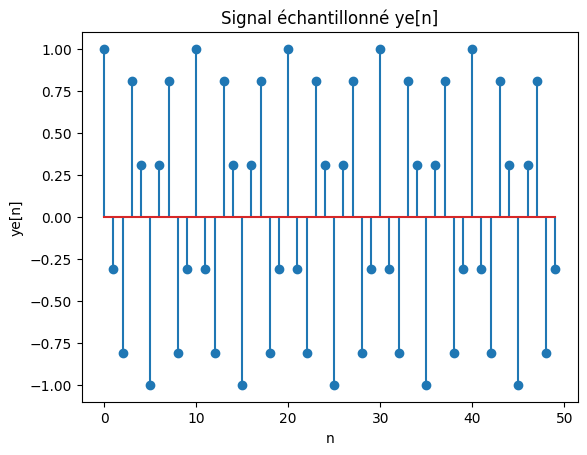

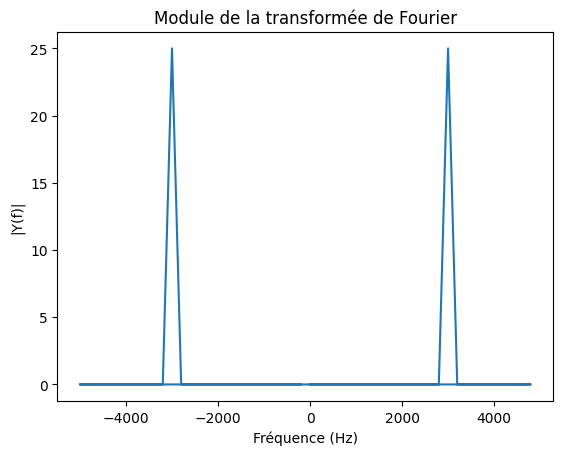

In [3]:
f0=3000
fe=10000
Te=1/fe
n = np.arange(0, 50)
ye=np.cos(2*np.pi*f0*n*Te)

plt.figure()
plt.stem(n, ye)
plt.xlabel("n")
plt.ylabel("ye[n]")
plt.title("Signal échantillonné ye[n]")
plt.show()

Y = np.fft.fft(ye)
freq = np.fft.fftfreq(len(ye), d=1/fe)

plt.figure()
plt.plot(freq, np.abs(Y))
plt.xlabel("Fréquence (Hz)")
plt.ylabel("|Y(f)|")
plt.title("Module de la transformée de Fourier")
plt.show()

2) On fixe $fe = 4kHz$. Représenter le signal temporel et le module de sa transformée de Fourier sur deux figures différentes. Conclure.

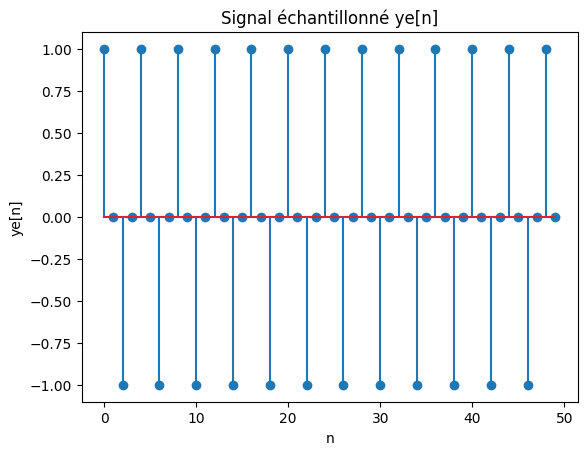

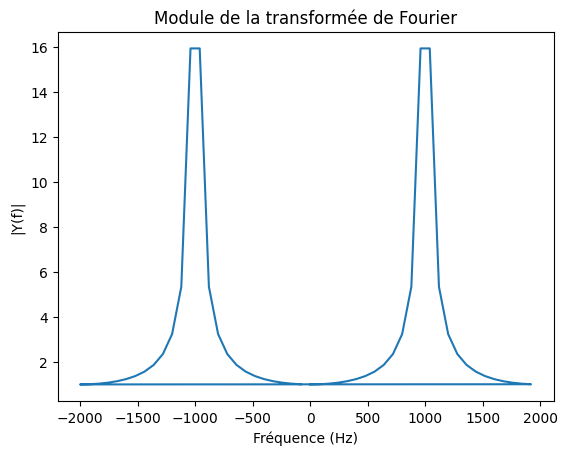

In [4]:
fe=4000
Te=1/fe
ye=np.cos(2*np.pi*f0*n*Te)

plt.figure()
plt.stem(n, ye)
plt.xlabel("n")
plt.ylabel("ye[n]")
plt.title("Signal échantillonné ye[n]")
plt.show()

Y = np.fft.fft(ye)
freq = np.fft.fftfreq(len(ye), d=1/fe)

plt.figure()
plt.plot(freq, np.abs(Y))
plt.xlabel("Fréquence (Hz)")
plt.ylabel("|Y(f)|")
plt.title("Module de la transformée de Fourier")
plt.show()


*Commentaires (fréquence d'échantillonnage)*: Nous avons du Alliasing vu que fe<2*fmax, fe<6KHz

3) Charger, à l’aide de scipy.io.wavfile, le son "handel" qui a été échantillonné à la fréquence d’échantillonnage $fe = 8192Hz$ et quantifié sur 16 bits.

In [5]:
import scipy.io.wavfile as wav 
fs, signal = wav.read('handel.wav')
print(fs)
print(signal.dtype)

8192
int16


4) Sous-échantillonner le signal sonore précédent d’un facteur 2 et écoutez-le. Conclure sur les effets du sous-échantionllonnage.

In [6]:
signal_sub = signal[::2]
fn = fs // 2

wav.write('handel_sub2.wav', fn, signal_sub)

*Commentaires (effets du sous-échantionllonnage)*: On a une forte perte de clarté dans le son

5) Sur-échantillonner le signal sonore précédent d’un facteur 2 et écoutez-le. Conclure sur les effets du sur-échantionllonnage.

In [7]:
signal_up = np.zeros(len(signal)*2, dtype=signal.dtype)
signal_up[::2] = signal

fn = fs * 2

wav.write('handel_up2.wav', fn, signal_up)

*Commentaires (effets du sur-échantionllonnage)*: On perds de la qualité avec l'ajout de grésillement

***

<h3><center>EXERCICE 2 : TRANSFORMÉE DE FOURIER ET FILTRAGE</center></h3>

Soit le signal $x(n) = (1/2)^n$  $u(n)$, avec $u(n)$ l’échelon unité. 

1) Calculer $X(f)$ la transformée de Fourier de $x(n)$, avec $n = −128, ..., −1, 0, 1, 2, ..., 128$. Représenter le module et la phase de $X(f)$. On rappelle que $f$ $∈$ $[$−1/2$,  $1/2$]$



257


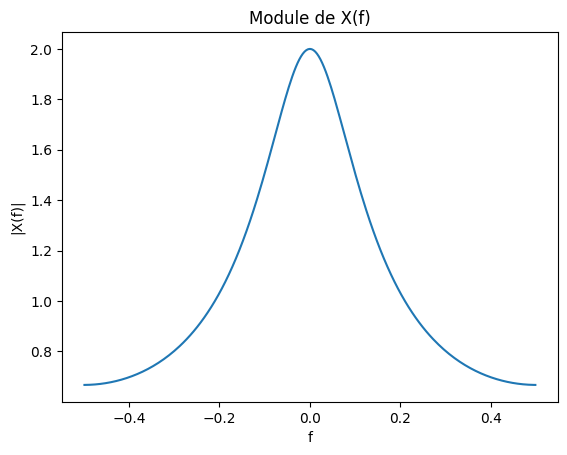

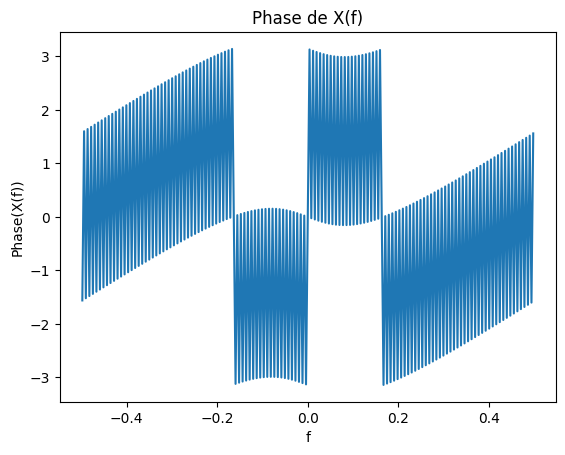

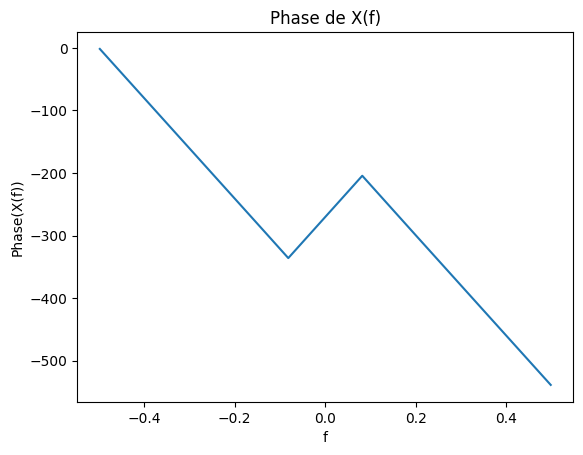

In [8]:
n = np.arange(-128,129)

x = (0.5)**n * (n >= 0)

X = np.fft.fftshift(np.fft.fft(x))

N = len(x)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1))
print(N)

# module
plt.figure()
plt.plot(f, np.abs(X))
plt.xlabel("f")
plt.ylabel("|X(f)|")
plt.title("Module de X(f)")
plt.show()

# phase
plt.figure()
plt.plot(f, np.angle(X))
plt.xlabel("f")
plt.ylabel("Phase(X(f))")
plt.title("Phase de X(f)")
plt.show()

# phase
plt.figure()
plt.plot(f, np.unwrap(np.angle(X)))
plt.xlabel("f")
plt.ylabel("Phase(X(f))")
plt.title("Phase de X(f)")
plt.show()

2) Quelle est la nature (passe-haut, bas, bande) de ce filtre?

*Commentaires*: C'est un filtre passe bas

3) On considère un filtre passe-bas idéal de fréquence de coupure 1/4. Représenter le module (dans le domaine de Fourier) de ce filtre.


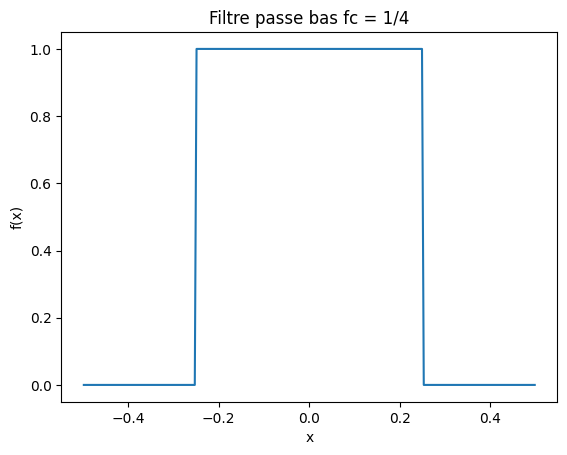

In [9]:
fc = 1/4

fpb = np.where(np.abs(f)<= fc,1,0)


plt.figure()
plt.plot(f, fpb)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Filtre passe bas fc = 1/4")
plt.show()



Soit $y(n) = cos(2πf1n)+cos(2πf2n)+cos(2πf3n)$, avec $n = −128, ..., −1, 0, 1, 2, ..., 128$ et $f1 = 1/5$, $f2 = 1/3$, $f3 = 2/5$.

4) Représenter y(n).

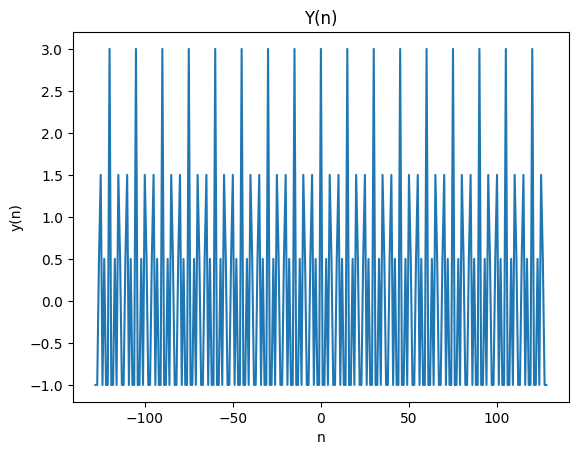

In [10]:
f1=1/5
f2=1/3
f3=2/5
y= np.cos(2*np.pi*f1*n)+np.cos(2*np.pi*f2*n)+np.cos(2*np.pi*f3*n)
plt.figure()
plt.plot(n, y)
plt.xlabel("n")
plt.ylabel("y(n)")
plt.title("Y(n)")
plt.show()

5) Quelle est la fréquence d’échantillonnage à laquelle est échantillonné le signal $y(n)$ ?

*Commentaires*:

6) On souhaite éliminer les fréquences $f2$ et $f3$.
Donner la nature et la fréquence de coupure du filtre à utiliser.

*Commentaires*: Il faut utiliser un filtre passe bas qui garde seulement f1 de fc = fmax/2 = 1/4

7) Réaliser le filtrage. Afficher le signal filtré temporel et sa transformée de Fourier sur deux figures différentes. Conclure.

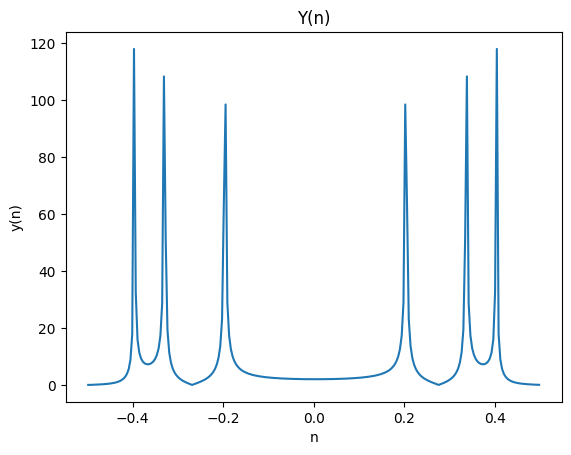

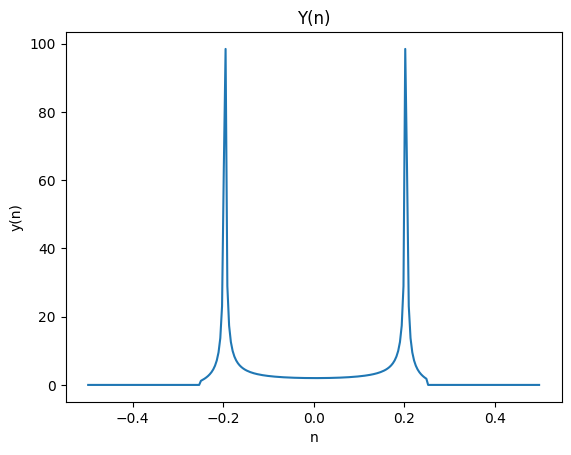

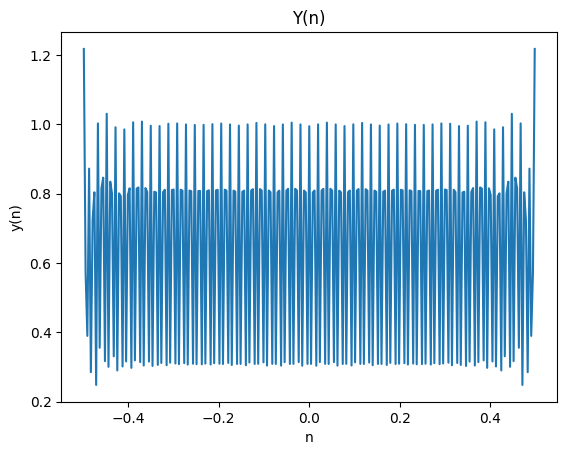

In [11]:
ff1 = 1/4
Yf = np.fft.ifftshift(np.fft.fft(y))
filtref1 = np.where(np.abs(f)<= ff1,1,0)
Yff1 = Yf*filtref1
plt.figure()
plt.plot(f, np.abs(Yf))
plt.xlabel("n")
plt.ylabel("y(n)")
plt.title("Y(n)")
plt.show()

plt.figure()
plt.plot(f, np.abs(Yff1))
plt.xlabel("n")
plt.ylabel("y(n)")
plt.title("Y(n)")
plt.show()

yf1 = np.fft.ifft(np.fft.ifftshift(Yff1))

plt.figure()
plt.plot(f, np.abs(yf1))
plt.xlabel("n")
plt.ylabel("y(n)")
plt.title("Y(n)")
plt.show()

*Commentaires*: 

8) Comment modifier le filtre passe-bas idéal pour éliminer $f1$ ? on inverse 1 et 0 pour le transformer en filtre passe haut.

*Commentaires*: 

9) Réaliser le filtrage. Afficher le signal filtré temporel et sa transformée de Fourier sur deux figures différentes. Conclure.

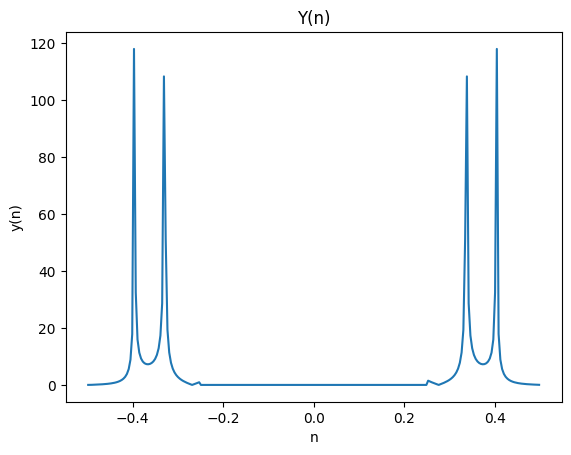

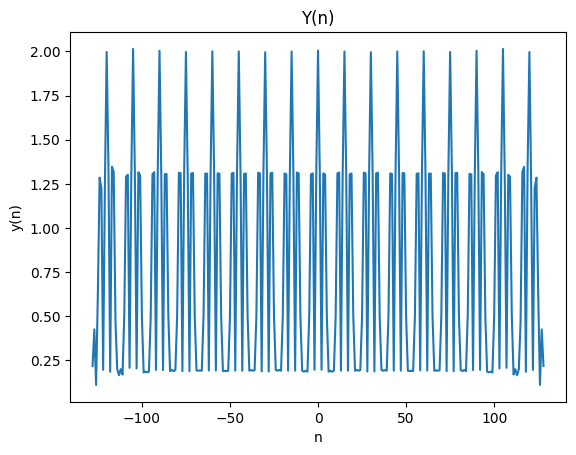

In [12]:
filtref1n = np.where(np.abs(f)<= ff1,0,1)
Yff23 = Yf*filtref1n

plt.figure()
plt.plot(f, np.abs(Yff23))
plt.xlabel("n")
plt.ylabel("y(n)")
plt.title("Y(n)")
plt.show()

yf23 = np.fft.ifft(np.fft.ifftshift(Yff23))

plt.figure()
plt.plot(n, np.abs(yf23))
plt.xlabel("n")
plt.ylabel("y(n)")
plt.title("Y(n)")
plt.show()

*Commentaires*: Il ne reste plus que f2 et f3 que l'on distingue par leur max.

***

<h3><center>EXERCICE 3 : FILTRAGE D’UN SIGNAL SONORE</center></h3>

Charger, à l’aide de scipy.io.wavfile, le son "handel" qui a été échantillonné à la fréquence d’échantillonnage $fe = 8192Hz$ et quantifié sur 16 bits.

8.9249267578125


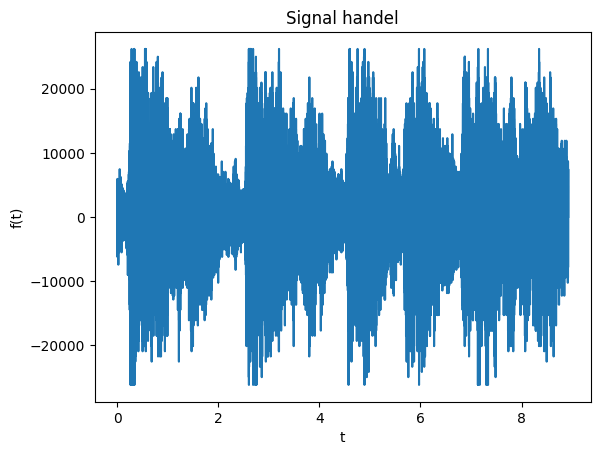

In [37]:
fs2, signal2 = wav.read('handel.wav')
print(len(signal2) / fs2)
t = np.arange(len(signal2)) / fe 
plt.figure()
plt.plot(t, signal2)
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Signal handel")
plt.show()


1) Quelle est la durée en secondes de ce signal sonore ?

*Commentaires*: Il a une durée d'environ 8.92 secondes

2) Calculer et afficher le module de la transformée de Fourier de ce signal sonore.

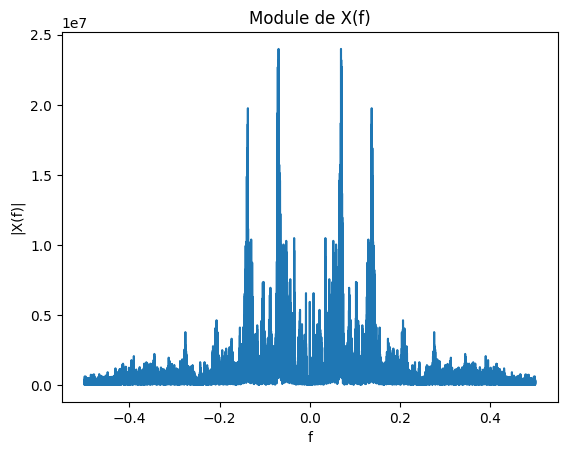

In [38]:
X = np.fft.fftshift(np.fft.fft(signal2))

N = len(signal2)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1))

# module
plt.figure()
plt.plot(f, np.abs(X))
plt.xlabel("f")
plt.ylabel("|X(f)|")
plt.title("Module de X(f)")
plt.show()

3) Générer un signal sinusoïdal, de fréquence 3 kHz, échantillonné à $fe = 8192Hz$, et de la même durée que le signal sonore "handel".

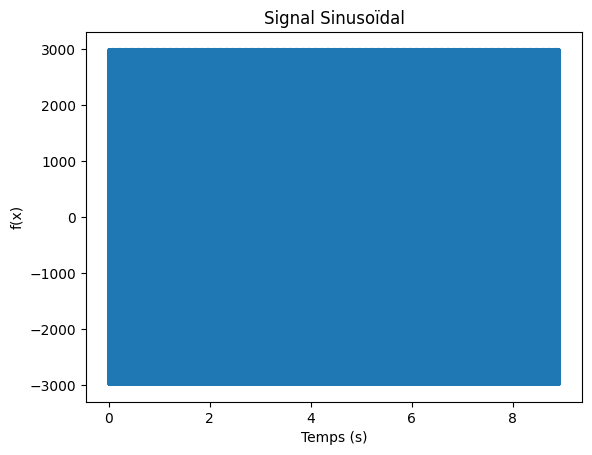

In [39]:
fe = fs2
duree = 8
f = 3000
A = 3000
N = len(signal2)
t = np.arange(N) / fe 
sin = A * np.sin(2 * np.pi * f * t)
plt.figure()
plt.plot(t, sin)
plt.xlabel("Temps (s)")
plt.ylabel("f(x)")
plt.title("Signal Sinusoïdal")
plt.show()

4) Additionner ce signal sinusoïdal au signal handel et écouter le signal résultant.

In [40]:
signal_sin = signal2 + sin

wav.write('handel_sin.wav', fs2, signal_sin.astype(np.int16))

5) Calculer et afficher le module de la transformée de Fourier du signal résultant.

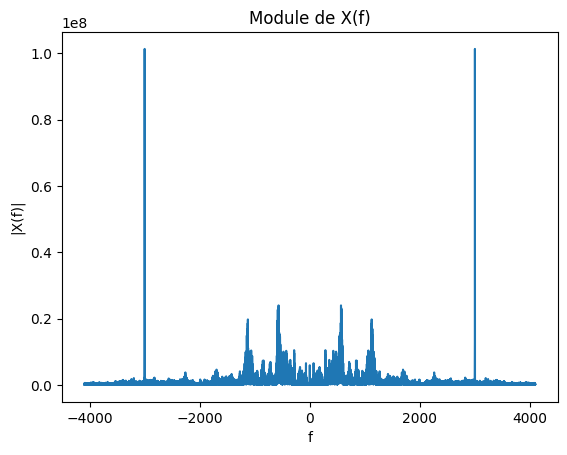

In [41]:

Ysin = np.fft.fftshift(np.fft.fft(signal_sin))

N = len(signal_sin)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs2))

# module
plt.figure()
plt.plot(f, np.abs(Ysin))
plt.xlabel("f")
plt.ylabel("|X(f)|")
plt.title("Module de X(f)")
plt.show()

6) Proposer une méthode pour filtrer le signal cosinus. Mettez-la en oeuvre et écouter le signal filtré.

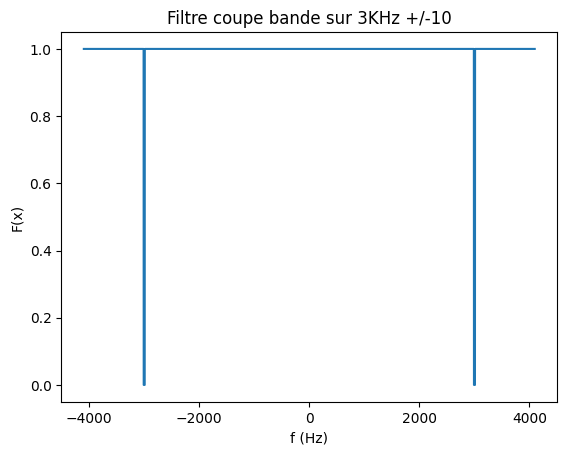

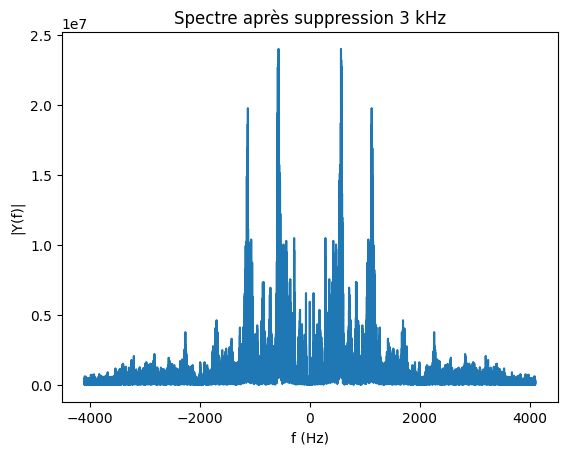

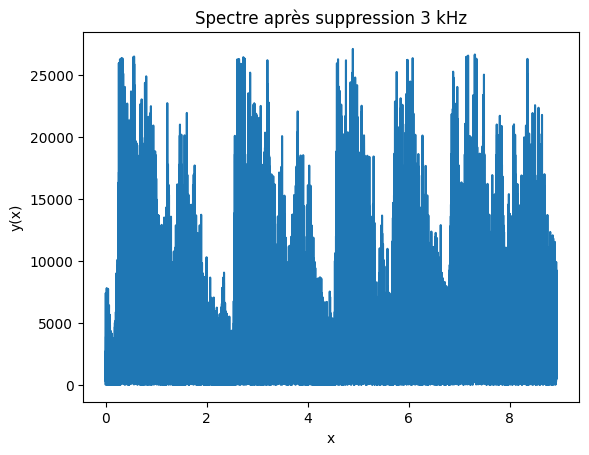

In [43]:
filtre = []
bande=3000
ecart=10
for i in f:
    if (bande-ecart <= i and i <= bande+ecart) or (-bande-ecart <= i and i <= -bande+ecart):
        filtre.append(0)
    else:
        filtre.append(1)

plt.figure()
plt.plot(f, filtre)
plt.xlabel("f (Hz)")
plt.ylabel("F(x)")
plt.title("Filtre coupe bande sur 3KHz +/-10")
plt.show()

Ycp = Ysin * filtre
ycp = np.fft.ifft(np.fft.ifftshift(Ycp))

plt.figure()
plt.plot(f, np.abs(Ycp))
plt.xlabel("f (Hz)")
plt.ylabel("|Y(f)|")
plt.title("Spectre après suppression 3 kHz")
plt.show()

plt.figure()
plt.plot(t, np.abs(ycp))
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Spectre après suppression 3 kHz")
plt.show()

*Commentaires (brève description de la méthode)*: Je vais utiliser un filtre coupe bande sur 3kHz +/- 10

7) Bruitez le signal sonore "handel" par un bruit Gaussien, additif, de moyenne nulle et d’écart-type 0, 5. Ecoutez le signal résultant.

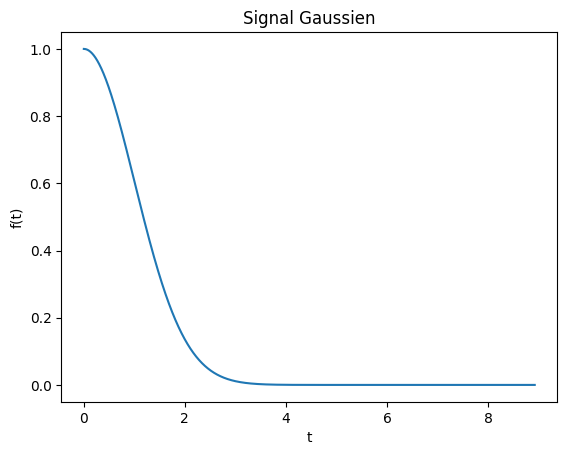

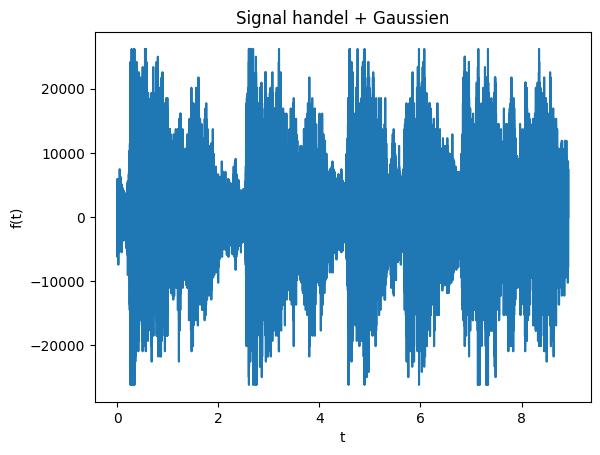

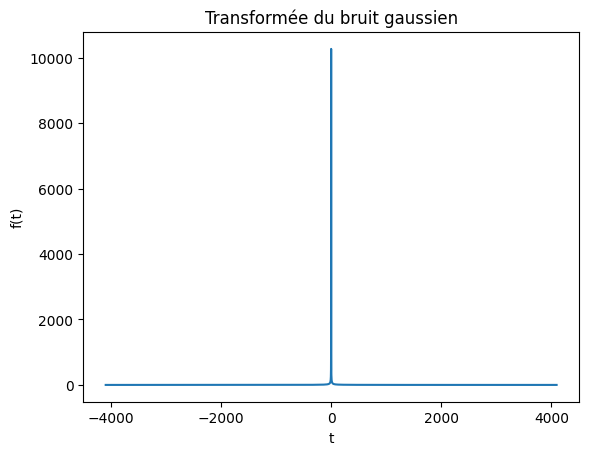

In [55]:
G = np.exp(-0.5*t*t)

plt.figure()
plt.plot(t, G)
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Signal Gaussien")
plt.show()

signalG = signal2 + G

wav.write('handelG.wav', fs2, signalG.astype(np.int16))

plt.figure()
plt.plot(t, signalG)
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Signal handel + Gaussien")
plt.show()

YG = np.fft.fftshift(np.fft.fft(G))

plt.figure()
plt.plot(f, np.abs(YG))
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Transformée du bruit gaussien")
plt.show()

8) Débruitez ce signal par le filtre précédent. Conclure.

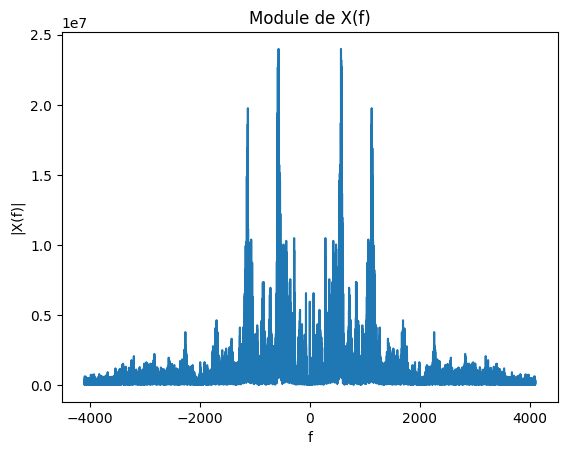

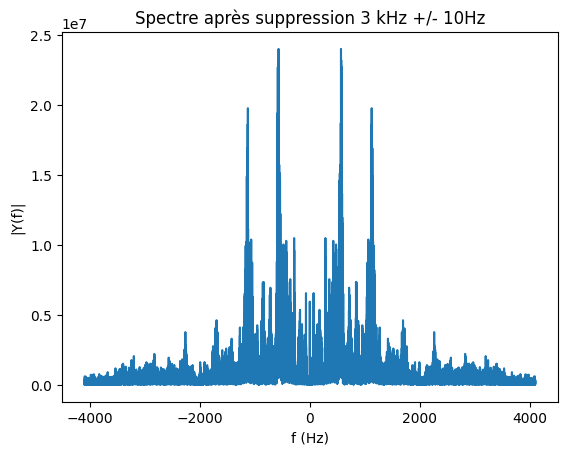

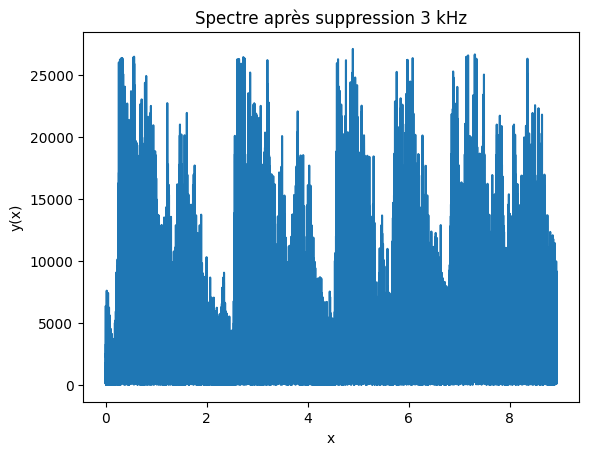

In [56]:
Ygau = np.fft.fftshift(np.fft.fft(signalG))
N = len(signalG)

plt.figure()
plt.plot(f, np.abs(Ygau))
plt.xlabel("f")
plt.ylabel("|X(f)|")
plt.title("Module de X(f)")
plt.show()

Ygf = Ygau * filtre
ygf = np.fft.ifft(np.fft.ifftshift(Ygf))

plt.figure()
plt.plot(f, np.abs(Ygf))
plt.xlabel("f (Hz)")
plt.ylabel("|Y(f)|")
plt.title("Spectre après suppression 3 kHz +/- 10Hz")
plt.show()

plt.figure()
plt.plot(t, np.abs(ygf))
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Spectre après suppression 3 kHz")
plt.show()

*Commentaires*: La transformée de Fourier du bruit Gaussien est un Dirac et donc ne modifie pas le signal. Puis le filtre en 3Khz ne fait rien car il y pas grand chose a enlever en 3KHz.

9) Générez 100 réalisations indépendantes du signal bruité par un bruit Gaussien et écoutez la moyenne temporelle de ces 100 signaux. Conclure.

*Commentaires*: 

***

<h3><center>EXERCICE 4 : SYNTHÈSE D’UN SIGNAL SONORE</center></h3>


1) Rechercher (sur Wikipédia par exemple) les fréquences des notes de musique de base. Par exemple, la fréquence du "do" sur "3 octave dans la gamme des tempérés" est $261,63 Hz$.

*Commentaires (fréquences des notes de musique)*: 

2) Ecrire un programme qui joue les notes "FRERE -JAC-QUES" suivi de "DORMEZ-VOUS". On expliquera comment choisir la fréquence d’échantillonnage.

*Commentaires (fréquence d’échantillonnage)*:

3) Lire la "musique" ainsi obtenue. Répétez-la 3 fois.

4) Question facultative. Ecrire un programme qui joue la berceuse précédente entièrement.